In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import netCDF4
import numpy as np
import xarray as xr
#import pandas as pd 
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
#from cartopy.util import add_cyclic_point
from windspharm.xarray import VectorWind
mpl.rcParams['mathtext.default'] = 'regular'
#import numpy as np
import cartopy.feature as feature

In [2]:
#path_sm = '/g/data/jk72/sm3719/'
#path_cmip = 'cmip6'
#path_ds = '/pictrl/CSIRO-MK3-6-0/climate_index/eof/IOBM-IOD/eof2_CSIRO-Mk3-6-0-iobm_kave.nc'

#xr.open_dataset(path_sm + path_cmip)

In [3]:
ds1=xr.open_dataset('/g/data/jk72/sm3719/cmip6/ESSD/regression/AMO/Regression_SST_spatial_pattern_AMO_ERSSTv5-23models.nc')
ds2=xr.open_dataset('/g/data/jk72/sm3719/cmip6/ESSD/regression/AMO/Regression_SST_spatial_pattern_AMO_MMM.nc')

AMO1=ds1['SLOPE'][0,:,:]
AMO2=ds1['SLOPE'][1,:,:]
AMO3=ds1['SLOPE'][2,:,:]
AMO4=ds1['SLOPE'][3,:,:]
AMO5=ds1['SLOPE'][4,:,:]
AMO6=ds1['SLOPE'][5,:,:]
AMO7=ds1['SLOPE'][6,:,:]
AMO8=ds1['SLOPE'][7,:,:]
AMO9=ds1['SLOPE'][8,:,:]
AMO10=ds1['SLOPE'][9,:,:]

print(ds1.coords)
#print(ds9)
#weight=ds9['clat']
#wslope1=slope1*weight
#weight.shape
print(ds1.coords)
LON = ds1.LON286_354.data
LAT = ds1.LAT91_151.data
LON=np.linspace(285,353,69)
LAT=np.linspace(0,60,61)
LON,LAT=np.meshgrid(LON,LAT)

#LON1 = ds9.LON.data
#LAT1 = ds9.LAT.data
#LON1=np.linspace(40,110,36)
#LAT1=np.linspace(-20,25,23)
#LON1,LAT1=np.meshgrid(LON1,LAT1)


Coordinates:
  * time        (time) float64 192B 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
  * LON286_354  (LON286_354) float64 552B 285.0 286.0 287.0 ... 352.0 353.0
  * LAT91_151   (LAT91_151) float64 488B 0.4986 1.496 2.493 ... 59.33 60.33
Coordinates:
  * time        (time) float64 192B 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
  * LON286_354  (LON286_354) float64 552B 285.0 286.0 287.0 ... 352.0 353.0
  * LAT91_151   (LAT91_151) float64 488B 0.4986 1.496 2.493 ... 59.33 60.33


In [4]:
AMO11=ds1['SLOPE'][10,:,:]
AMO12=ds1['SLOPE'][11,:,:]
AMO13=ds1['SLOPE'][12,:,:]
AMO14=ds1['SLOPE'][13,:,:]
AMO15=ds1['SLOPE'][14,:,:]
AMO16=ds1['SLOPE'][15,:,:]
AMO17=ds1['SLOPE'][16,:,:]
AMO18=ds1['SLOPE'][17,:,:]
AMO19=ds1['SLOPE'][18,:,:]
AMO20=ds1['SLOPE'][19,:,:]
AMO21=ds1['SLOPE'][20,:,:]
AMO22=ds1['SLOPE'][21,:,:]
AMO23=ds1['SLOPE'][22,:,:]
AMO24=ds1['SLOPE'][23,:,:]
AMO25=ds2['MMM'][:,:]

In [5]:
datasets = [
    (AMO1, "(a) ERSSTv5"),
    (AMO2, "(b) CanESM5"),
    (AMO3, "(c) HadGEM3-GC31-LL"),
    (AMO4, "(d) EC-Earth3-CC"),
    (AMO5, "(e) CMCC-CM2-SR5"),
    (AMO6, "(f) CNRM-CM6-1"),
    (AMO7, "(g) GISS-E2-1-G"),
    (AMO8, "(h) CMCC-ESM2"),
    (AMO9, "(i) EC-Earth3"),
    (AMO10, "(j) E3SM1-0"),
    (AMO11, "(k) MIROC6"),
    (AMO12, "(l) MRI-ESM2-0"),
    (AMO13, "(m) HadGEM3-GC31-MM"),
    (AMO14, "(n) BCC-CSM2-MR"),
    (AMO15, "(o) IPSL-CM6A-LR"),
    (AMO16, "(p) MPI-ESM1-2-HR"),
    (AMO17, "(q) ACCESS-ESM1-5"),
    (AMO18, "(r) ACCESS-CM2"),
    (AMO19, "(s) CESM2"),
    (AMO20, "(t) GFDL-CM4"),
    (AMO21, "(u) CIESM"),
    (AMO22, "(v) FGOALS-g3"),
    (AMO23, "(w) SAM0-UNICON"),
    (AMO24, "(x) CNRM-ESM2-1"),
    (AMO25, "(y) MMM")
]

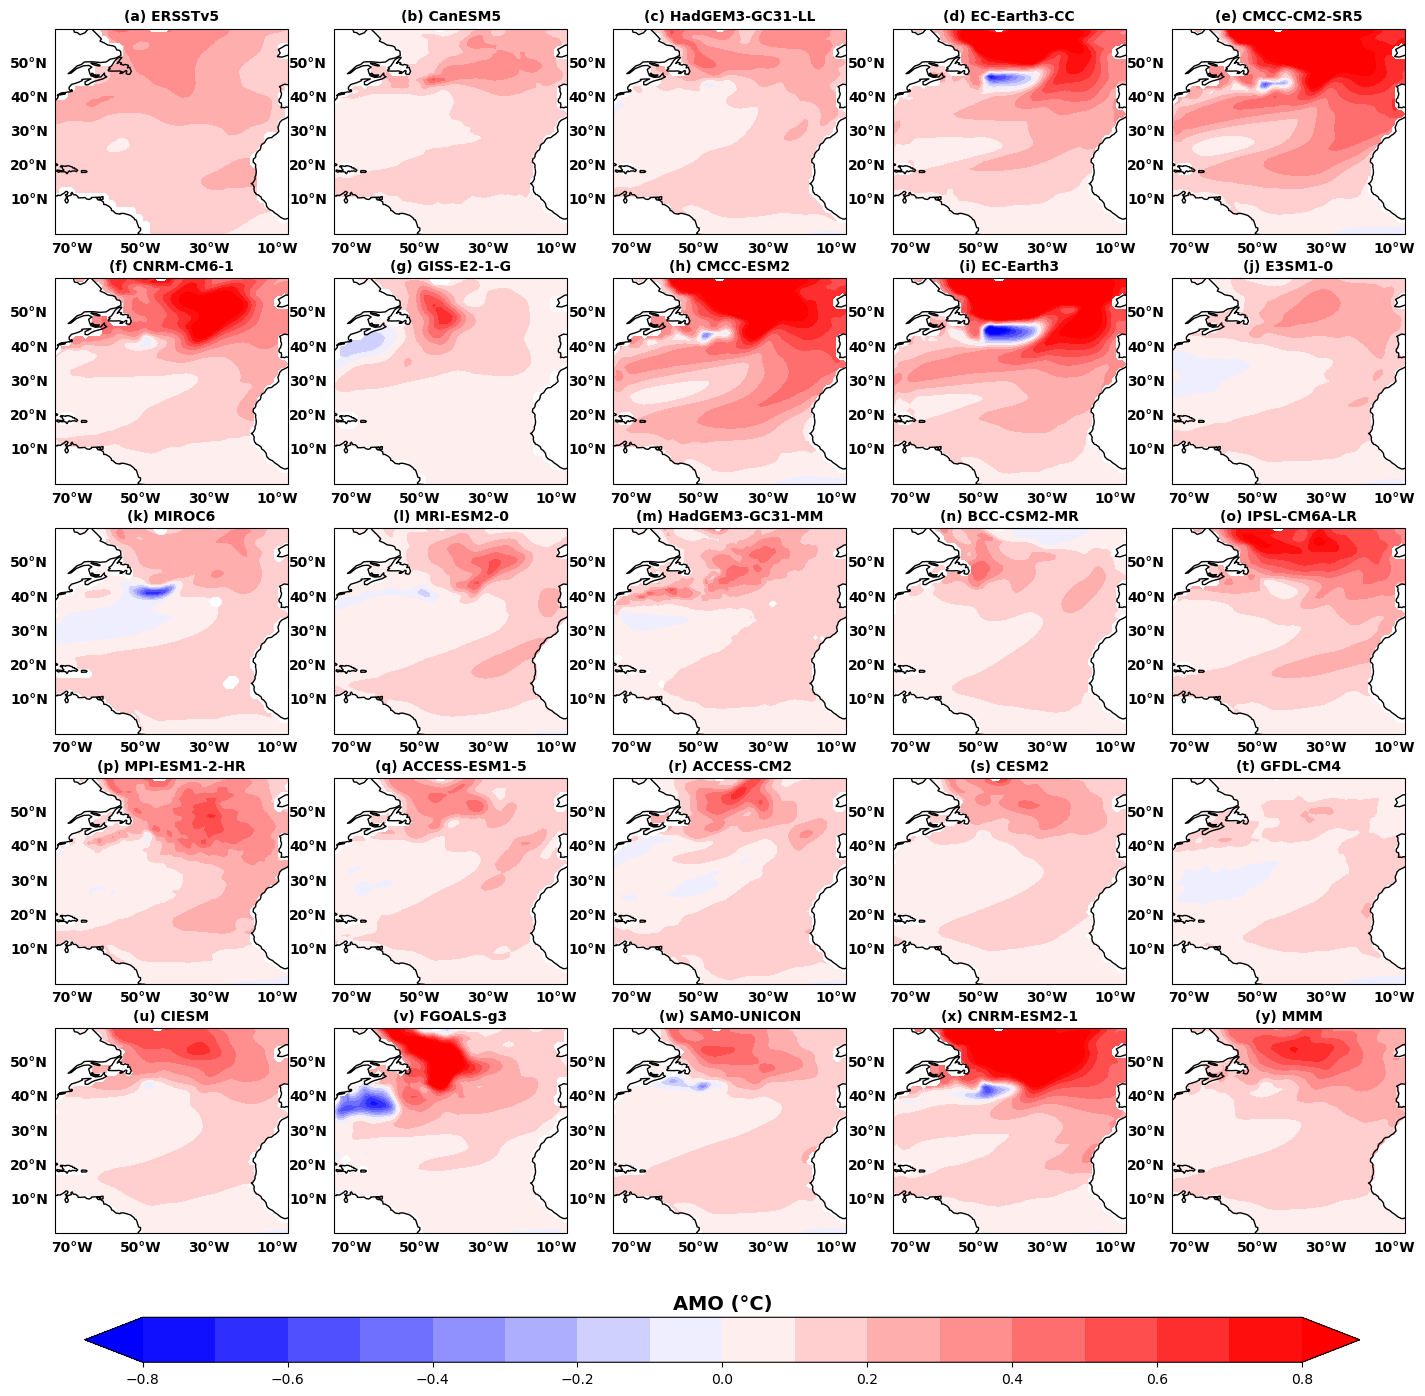

In [6]:
# Subplot configuration
nrows, ncols = 5, 5
start_index = 1  # Starting index for subplots
projection = ccrs.PlateCarree(central_longitude=0)
clevs = np.arange(-0.8, 0.9, 0.1)

# Create figure
fig = plt.figure(figsize=(15, 22.5))
# Store the last `contourf` plot for the colorbar
last_fill_sf = None

for i, (data, title) in enumerate(datasets, start=start_index):
    ax = plt.subplot(nrows, ncols, i, projection=projection)
    fill_sf = ax.contourf(
        LON, LAT, data, levels=clevs, cmap=plt.cm.bwr, 
        transform=ccrs.PlateCarree(), extend='both'
    )
    last_fill_sf = fill_sf  # Update the last contourf object
    ax.set_aspect('equal')
    ax.coastlines()
    ax.set_title(title, fontsize=10, loc='center', color='black', fontweight='bold')
#    ax.annotate(annotation, xy=(0.5, -0.11), xycoords='axes fraction', ha='center', va='top', fontsize=10, color='red', fontweight='bold')
    # Gridlines
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True)
# --- Longitude labels ---
    gl.top_labels = False       # no longitude labels on top
    gl.bottom_labels = True     # show longitude labels only on the bottom
# --- Latitude labels ---
    gl.left_labels = True       # keep latitude labels on the left
    gl.right_labels = False     # no latitude labels on the right
# --- Gridline drawing ---
    gl.xlines = False           # don't draw the longitude gridlines themselves
    gl.ylines = False           # don't draw the latitude gridlines themselves
# --- Formatters ---
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {'size': 10, 'weight': 'bold'}
    gl.ylabel_style = {'size': 10, 'weight': 'bold'}

# Adjust layout (moved outside the `if` block)
plt.subplots_adjust(bottom=0.4, left=0.08, right=0.98, top=0.95, hspace=0.05)

# Add colorbar
if last_fill_sf is not None:  # Check if a valid contourf object exists
    cax = plt.axes([0.1, 0.35, 0.85, 0.02])  # Adjust these values for proper placement
    clb = plt.colorbar(last_fill_sf, cax=cax, orientation='horizontal', fraction=0.1, pad=0.05)
    clb.ax.set_title('AMO (°C)', loc='center', color='black', fontsize=14, fontweight='bold')

# Save and show plot
plt.savefig('/g/data/jk72/sm3719/cmip6/ESSD/climate_mode/panel25_regression_AMO_models_observations_mmm.png', dpi=600)
plt.show()